In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [3]:
image_tensor = torchvision.io.read_image("data/naruto_sasuke.jpg")

image_tensor = image_tensor.float() / 255.0

In [4]:
def add_noise(img):
    return img + torch.randn(img.size()) * 0.02

In [5]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T)

def add_noise_formula(img, t):
    beta_t = betas[t]
    if isinstance(t, torch.Tensor) and t.ndim > 0:
        view_shape = [img.shape[0]] + [1] * (img.ndim - 1)
        beta_t = beta_t.view(*view_shape)
    
    mean_coef = torch.sqrt(1.0 - beta_t)
    std = torch.sqrt(beta_t)
    
    noise = torch.randn_like(img)
    return mean_coef * img + std * noise

In [6]:
T2 = 1000
betas2 = torch.linspace(1e-4, 0.01, T2)

# Precompute these once when you initialize your model/class
alphas = 1.0 - betas2
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_noisy_image_instant(x_0, t):
    # Get alpha_cumprod for the specific timestep(s)
    a_t = alphas_cumprod[t].view(-1, 1, 1, 1) # Reshape for broadcasting
    
    # Generate noise
    noise = torch.randn_like(x_0)
    
    # Closed-form formula: x_t = sqrt(a_bar)*x_0 + sqrt(1 - a_bar)*noise
    noisy_img = torch.sqrt(a_t) * x_0 + torch.sqrt(1.0 - a_t) * noise
    return noisy_img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07960747..1.0704669].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.895221..1.7495527].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3835136..2.0480845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5732518..2.3306792].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7598072..2.5233393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0710561..2.6904721].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.091822

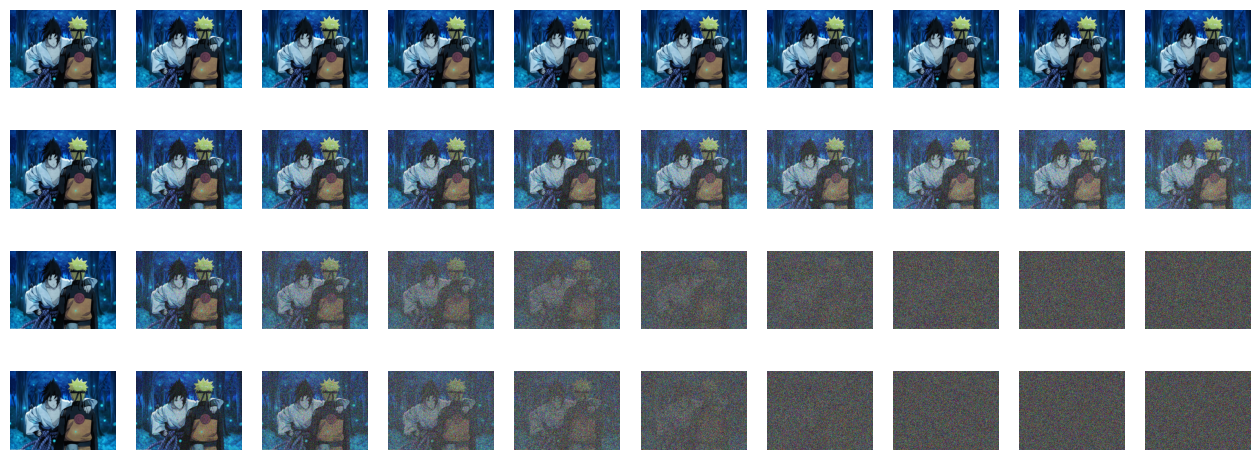

In [7]:
fig, axes = plt.subplots(4, 10, figsize=(16, 6))

for i in range(10):
    img = image_tensor.detach().cpu()
    img = img.permute(1, 2, 0)  # Shape [C, H, W] -> [H, W, C]
    axes[0][i].imshow(img)
    axes[0][i].axis('off')

img2 = image_tensor
img2 = img2.permute(1, 2, 0)  # Shape [C, H, W] -> [H, W, C]
for i in range(10):
    img2 = add_noise(img2)
    img2 = img2.detach().cpu()
    axes[1][i].imshow(img2)
    axes[1][i].axis('off')
    for j in range(100):
        img2 = add_noise(img2)


img3 = image_tensor
img3 = img3.permute(1, 2, 0)  # Shape [C, H, W] -> [H, W, C]
for i in range(10):
    img3 = add_noise_formula(img3, i*100)
    img3 = img3.detach().cpu()
    axes[2][i].imshow(img3)
    axes[2][i].axis('off')
    for j in range(100):
        img3 = add_noise_formula(img3, i*100 + j)
    
img4 = image_tensor
for i in range(10):
    img4 = get_noisy_image_instant(img4, i*100)
    axes[3][i].imshow(img4.detach().cpu().squeeze().permute(1, 2, 0))
    axes[3][i].axis('off')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1072724..1.8784837].


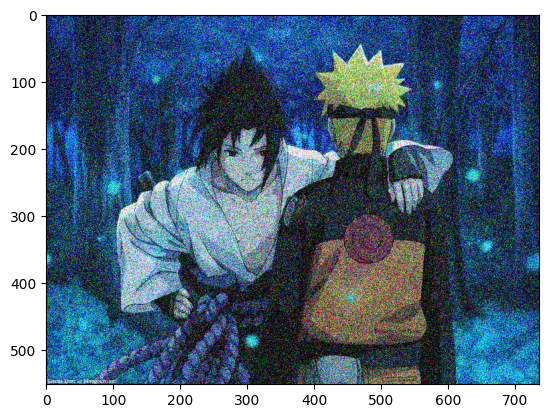

In [77]:
img = image_tensor.permute((1,2,0))
img = get_noisy_image_instant(img, 99)
plt.imshow(img.squeeze())